In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

### Loading Data

In [ ]:
training_data = datasets.CIFAR10(root="data", train=True, download=True, transform=ToTensor())
test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=ToTensor())

classes = training_data.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
training_data, validation_data = torch.utils.data.random_split(training_data, [40000, 10000])

In [ ]:
print(len(training_data),len(validation_data),len(test_data))

40000 10000 10000


## **Simple CNN**

  ### **~ Model 1 ~**

In [ ]:
def simple_cnn(units = [3*32*32, 10]):
    model = torch.nn.Sequential()
    model.add_module('conv_1', torch.nn.Conv2d(in_channels= 3, out_channels= 16, kernel_size=3, padding='same', stride = 1))
    model.add_module('relu_2', torch.nn.ReLU())
    model.add_module('maxpool_3', torch.nn.MaxPool2d(kernel_size= 2, stride= 2))
    model.add_module('conv_4', torch.nn.Conv2d(in_channels= 16, out_channels= 32, kernel_size=3))
    model.add_module('relu_5', torch.nn.ReLU())
    model.add_module('maxpool_6', torch.nn.MaxPool2d(kernel_size= 2, stride= 2))
    model.add_module('flatten', torch.nn.Flatten())   # flatten before last layer
    model.add_module('linear_7', torch.nn.Linear(32*7*7, units[1]))
    return model

In [ ]:
def train_eval(model, lr, nepochs, nbatch, training_data, validation_data, output=True):
    cost_hist = []
    cost_hist_test = []
    acc_hist = []
    acc_hist_test = []

    cost_ce = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
    test_loader = DataLoader(validation_data, batch_size=nbatch, shuffle=True)

    for epoch in range(nepochs):
        start=time.time()
        model.train()
        size = len(training_loader.dataset)
        nbatches = len(training_loader)
        cost, acc = 0.0, 0.0
        for batch, (X, Y) in enumerate(training_loader):
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        cost /= nbatches
        acc /= size

        model.eval()
        size_test = len(test_loader.dataset)
        nbatches_test = len(test_loader)
        cost_test, acc_test = 0.0, 0.0
        with torch.no_grad():
            for X, Y in test_loader:
                pred = model(X)
                cost_test += cost_ce(pred, Y).item()
                acc_test += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
        cost_test /= nbatches_test
        acc_test /= size_test
        end=time.time()
        if output:
            print("Epoch %i (dt=%1.2f s): %f, %f, %f, %f"%(epoch, end-start, cost, acc, cost_test, acc_test))
        cost_hist.append(cost)
        cost_hist_test.append(cost_test)
        acc_hist.append(acc)
        acc_hist_test.append(acc_test)
    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             448
              ReLU-2           [-1, 16, 32, 32]               0
         MaxPool2d-3           [-1, 16, 16, 16]               0
            Conv2d-4           [-1, 32, 14, 14]           4,640
              ReLU-5           [-1, 32, 14, 14]               0
         MaxPool2d-6             [-1, 32, 7, 7]               0
           Flatten-7                 [-1, 1568]               0
            Linear-8                   [-1, 10]          15,690
Total params: 20,778
Trainable params: 20,778
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.40
Params size (MB): 0.08
Estimated Total Size (MB): 0.49
----------------------------------------------------------------
Epoch 0 (dt=32.94 s): 1.752286, 0.378150, 1.

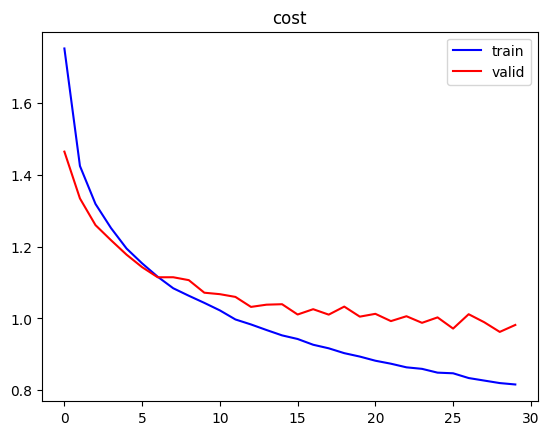

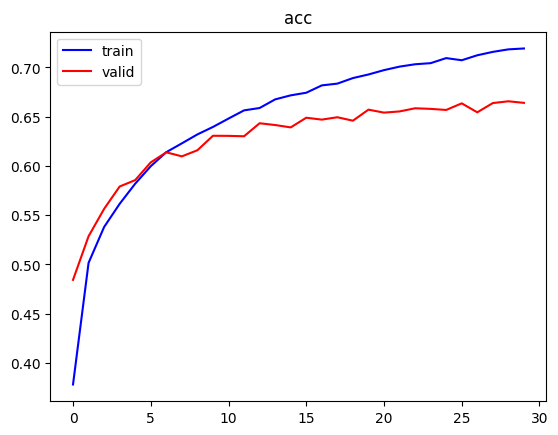

test accuracy: 67.2%


In [ ]:
nbatch = 128
nepochs = 30
lr = 0.001

size_in = training_data[0][0].shape
simple_cnn_model = simple_cnn()
summary(simple_cnn_model, size_in)

cost_train, cost_valid, acc_train, acc_valid = train_eval(simple_cnn_model, lr, nepochs,
                                nbatch, training_data, validation_data)

plt.figure(1)
plt.plot(range(len(cost_train)), cost_train, "b-", label='train')
plt.plot(range(len(cost_valid)), cost_valid, "r-", label='valid')
plt.legend()
plt.title('cost')
plt.show()

plt.figure(2)
plt.plot(range(len(acc_train)), acc_train, "b-", label='train')
plt.plot(range(len(acc_valid)), acc_valid, "r-", label='valid')
plt.legend()
plt.title('acc')
plt.show()

len_test = len(test_data)
test_loader = DataLoader(test_data, batch_size=len_test, shuffle=False)
X, Y = next(iter(test_loader))
pred = simple_cnn_model(X)

acc_test = (pred.argmax(dim=1) == Y).type(torch.float).sum().item() / len_test

print(f'test accuracy: {100*acc_test:.1f}%')

> We obtain an accuracy of 67,2 % for the test. This is far more better than the accuracy of 46% with an MLP.

## **Deeper CNN**





### **~ Model 2~**

Adding a Conv2D and a Maxpool layer.

In [ ]:
def deeper_cnn(units = [3*32*32, 10]):
    model = torch.nn.Sequential()
    model.add_module('conv_1', torch.nn.Conv2d(in_channels= 3, out_channels= 16, kernel_size=3, padding='same', stride = 1))
    model.add_module('relu_2', torch.nn.ReLU())
    model.add_module('maxpool_3', torch.nn.MaxPool2d(kernel_size= 2, stride= 2))
    model.add_module('conv_4', torch.nn.Conv2d(in_channels= 16, out_channels= 32, kernel_size=3))
    model.add_module('relu_5', torch.nn.ReLU())
    model.add_module('maxpool_6', torch.nn.MaxPool2d(kernel_size= 2, stride= 2)) #réduit hauteur et largeur mais pas le nombre de canneaux
    model.add_module('conv_7', torch.nn.Conv2d(in_channels= 32, out_channels= 32, kernel_size=3))
    model.add_module('relu_8', torch.nn.ReLU())
    model.add_module('maxpool_9', torch.nn.MaxPool2d(kernel_size= 2, stride= 2))
    model.add_module('flatten_10', torch.nn.Flatten())
    model.add_module('linear_11', torch.nn.Linear(32*2*2, units[1]))
    return model

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             448
              ReLU-2           [-1, 16, 32, 32]               0
         MaxPool2d-3           [-1, 16, 16, 16]               0
            Conv2d-4           [-1, 32, 14, 14]           4,640
              ReLU-5           [-1, 32, 14, 14]               0
         MaxPool2d-6             [-1, 32, 7, 7]               0
            Conv2d-7             [-1, 32, 5, 5]           9,248
              ReLU-8             [-1, 32, 5, 5]               0
         MaxPool2d-9             [-1, 32, 2, 2]               0
          Flatten-10                  [-1, 128]               0
           Linear-11                   [-1, 10]           1,290
Total params: 15,626
Trainable params: 15,626
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/ba

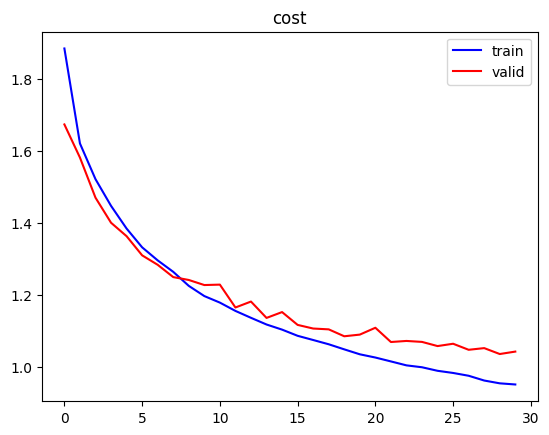

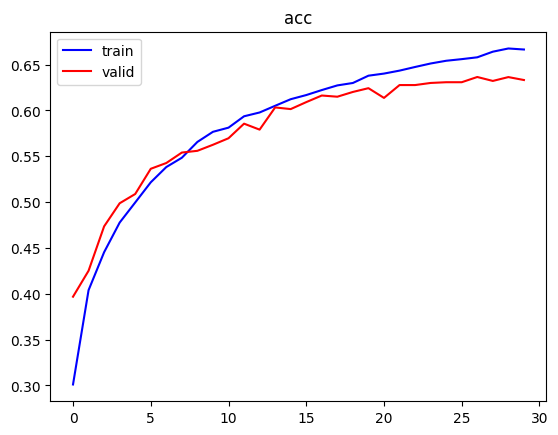

test accuracy: 63.6%


In [ ]:
nbatch = 128
nepochs = 30
lr = 0.001

size_in = training_data[0][0].shape
deeper_cnn_model = deeper_cnn()
summary(deeper_cnn_model, size_in)

cost_train2, cost_valid2, acc_train2, acc_valid2 = train_eval(deeper_cnn_model, lr, nepochs,
                                nbatch, training_data, validation_data)

plt.figure(1)
plt.plot(range(len(cost_train2)), cost_train2, "b-", label='train')
plt.plot(range(len(cost_valid2)), cost_valid2, "r-", label='valid')
plt.legend()
plt.title('cost')
plt.show()

plt.figure(2)
plt.plot(range(len(acc_train2)), acc_train2, "b-", label='train')
plt.plot(range(len(acc_valid2)), acc_valid2, "r-", label='valid')
plt.legend()
plt.title('acc')
plt.show()

len_test = len(test_data)
test_loader = DataLoader(test_data, batch_size=len_test, shuffle=False)
X, Y = next(iter(test_loader))
pred2 = deeper_cnn_model(X)

acc_test2 = (pred2.argmax(dim=1) == Y).type(torch.float).sum().item() / len_test

print(f'test accuracy: {100*acc_test2:.1f}%')

> We obtain an accuracy of 63.6% for the test.

### **~ Model 3 ~**
Increasing the size of the kernel

In [ ]:
def deeper_cnn2(units = [3*32*32, 10]):
    model = torch.nn.Sequential()
    model.add_module('conv_1', torch.nn.Conv2d(in_channels= 3, out_channels= 16, kernel_size=5, padding='same', stride = 1))
    model.add_module('relu_2', torch.nn.ReLU())
    model.add_module('maxpool_3', torch.nn.MaxPool2d(kernel_size= 5, stride= 2))
    model.add_module('conv_4', torch.nn.Conv2d(in_channels= 16, out_channels= 32, kernel_size=5))
    model.add_module('relu_5', torch.nn.ReLU())
    model.add_module('maxpool_6', torch.nn.MaxPool2d(kernel_size= 5, stride= 2))
    model.add_module('flatten', torch.nn.Flatten())
    model.add_module('linear_7', torch.nn.Linear(32*7*7, units[1]))
    return model

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             448
              ReLU-2           [-1, 16, 32, 32]               0
         MaxPool2d-3           [-1, 16, 16, 16]               0
            Conv2d-4           [-1, 32, 14, 14]           4,640
              ReLU-5           [-1, 32, 14, 14]               0
         MaxPool2d-6             [-1, 32, 7, 7]               0
            Conv2d-7             [-1, 32, 5, 5]           9,248
              ReLU-8             [-1, 32, 5, 5]               0
         MaxPool2d-9             [-1, 32, 2, 2]               0
          Flatten-10                  [-1, 128]               0
           Linear-11                   [-1, 10]           1,290
Total params: 15,626
Trainable params: 15,626
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/ba

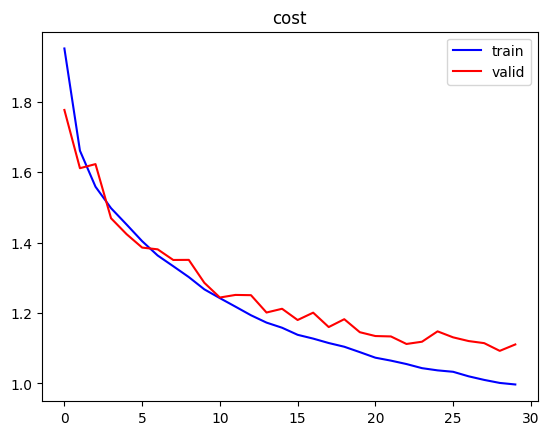

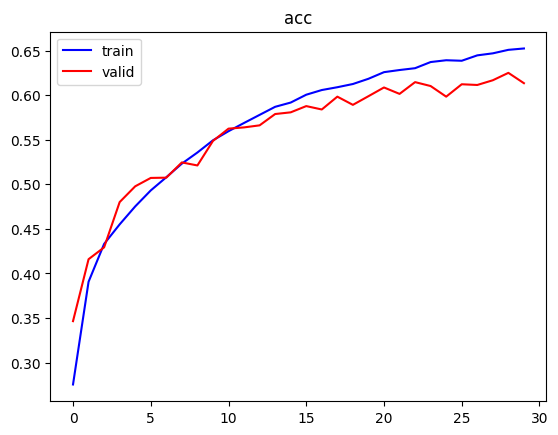

test accuracy: 61.8%


In [ ]:
nbatch = 128
nepochs = 30
lr = 0.001

size_in = training_data[0][0].shape
deeper_cnn_2 = deeper_cnn()
summary(deeper_cnn_2, size_in)

cost_train3, cost_valid3, acc_train3, acc_valid3 = train_eval(deeper_cnn_2, lr, nepochs,
                                nbatch, training_data, validation_data)

plt.figure(1)
plt.plot(range(len(cost_train3)), cost_train3, "b-", label='train')
plt.plot(range(len(cost_valid3)), cost_valid3, "r-", label='valid')
plt.legend()
plt.title('cost')
plt.show()

plt.figure(2)
plt.plot(range(len(acc_train3)), acc_train3, "b-", label='train')
plt.plot(range(len(acc_valid3)), acc_valid3, "r-", label='valid')
plt.legend()
plt.title('acc')
plt.show()

len_test = len(test_data)
test_loader = DataLoader(test_data, batch_size=len_test, shuffle=False)
X, Y = next(iter(test_loader))
pred3 = deeper_cnn_2(X)

acc_test3 = (pred3.argmax(dim=1) == Y).type(torch.float).sum().item() / len_test

print(f'test accuracy: {100*acc_test3:.1f}%')

> We obtain an accuracy of 61.8% for the test.

 **Model 1** :    


1.   Conv : in = 3, out = 16, w = h = 3, S = 1, P = 'same', kernel_size = 3
2.   ReLU
3.   Maxpool : kernel_size= 2, S = 2
4.   Conv : in = 16, out = 32, w = h = 3, S = 1, P = 'same'
5.   ReLU
6.   Maxpool : kernel_size= 2, S = 2
7.   Flatten
8.   Linear

>> **acc train** : 71.9 %

>> **acc test** :  67.2%


 **Model 2** :


1.   Conv : in = 3, out = 16, w = h = 3, S = 1, P = 'same', kernel_size = 3
2.   ReLU
3.   Maxpool : kernel_size= 2, S = 2
4.   Conv = 32, w = h = 3, S = 1, P = 'same'
5.   ReLU
6.   Maxpool : kernel_size= 2, S = 2
7.   Conv = 32, w = h = 3, S = 1, P = 'same'
8.   ReLU
9.   Maxpool : kernel_size= 2, S = 2
10.   Flatten
11.   Linear

>> **acc train** : 66.6%

>> **acc test** : 63.6%



 **Model 3** :    


1.   Conv : in = 3, out = 16, w = h = 3, S = 1, P = 'same', kernel_size = 5
2.   ReLU
3.   Maxpool : kernel_size= 5, S = 2
4.   Conv : in = 16, out = 32, w = h = 3, S = 1, P = 'same'
5.   ReLU
6.   Maxpool : kernel_size= 5, S = 2
7.   Flatten
8.   Linear

>> **acc train** : 65.2%

>> **acc test** : 61.8%
